## CAMELS L50n512 merger tree: interpolated formation times (SB25_0)

note: paths specific for sdsc-binder. Set `box` in the config cell to run a different box.

**Fast approach (propagate z=0 selection down the tree):**

1. Select present-day (snap 90) central halos with **absolute M200c > 1e11 Msun**
   (`log10(Group_M_Crit200 * 1e10 / h) > 11`; cosmology read from the box header).
2. For each, walk its SubLink main-progenitor branch **once** (read directly from
   `tree_extended.hdf5`, since `il.sublink.loadTree`'s offsets don't resolve on CAMELS)
   and compute **interpolated formation times**: the age at which the main-branch M200c
   first reached 10%, 25%, 50%, 90% of the z=0 root mass (cubic interpolation).
3. Propagate down the branch, tagging every snapshot with its `GroupNumber`
   (`SubhaloGrNr`) and `GroupFirstSub` (`SubfindID`).

Output table columns: `GroupNumber, GroupFirstSub, M200c_snap, M200c_z0,
SplashbackFlag, t_form_10, t_form_25, t_form_50, t_form_90` -- one DataFrame per
snapshot (0..90), saved into a single HDF5 file. Masses are in **physical Msun**.

In [3]:
import numpy as np
import illustris_python as il
import pickle
import h5py
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic
from scipy.interpolate import interp1d
import scipy
import matplotlib
import time
import pandas as pd
from tqdm import tqdm
import astropy.units as u
from astropy.constants import k_B, m_p

In [18]:
# --- box configuration (CAMELS IllustrisTNG, L50n512) ---
box   = 'SB35_0'
suite = box.rsplit('_', 1)[0]          # 'SB25'
base_snap = 90                          # z=0 snapshot for these boxes
n_snap    = 91                          # snapshots 0..90

basePath  = f'/home/jovyan/FOF_Subfind/IllustrisTNG/L50n512/{suite}/{box}'
tree_path = (f'/home/jovyan/PUBLIC_RELEASE/SubLink/IllustrisTNG/L50n512/'
             f'{suite}/{box}/tree_extended.hdf5')

groups = il.groupcat.loadHalos(basePath, base_snap,
                               fields=['GroupFirstSub', 'Group_M_Crit200'])

In [20]:
# confirm the tree fields (tree_path comes from the config cell above)
with h5py.File(tree_path, 'r') as f:
    print(list(f.keys()))

['DescendantID', 'FirstProgenitorID', 'FirstSubhaloInFOFGroupID', 'GroupBHMass', 'GroupBHMdot', 'GroupCM', 'GroupFirstSub', 'GroupGasMetalFractions', 'GroupGasMetallicity', 'GroupLen', 'GroupLenType', 'GroupMass', 'GroupMassType', 'GroupNsubs', 'GroupPos', 'GroupSFR', 'GroupStarMetalFractions', 'GroupStarMetallicity', 'GroupVel', 'GroupWindMass', 'Group_M_Crit200', 'Group_M_Crit500', 'Group_M_Mean200', 'Group_M_TopHat200', 'Group_R_Crit200', 'Group_R_Crit500', 'Group_R_Mean200', 'Group_R_TopHat200', 'LastProgenitorID', 'MainLeafProgenitorID', 'Mass', 'MassHistory', 'NextProgenitorID', 'NextSubhaloInFOFGroupID', 'NumParticles', 'RootDescendantID', 'SnapNum', 'SubfindID', 'SubhaloBHMass', 'SubhaloBHMdot', 'SubhaloBfldDisk', 'SubhaloBfldHalo', 'SubhaloCM', 'SubhaloGasMetalFractions', 'SubhaloGasMetalFractionsHalfRad', 'SubhaloGasMetalFractionsMaxRad', 'SubhaloGasMetalFractionsSfr', 'SubhaloGasMetalFractionsSfrWeighted', 'SubhaloGasMetallicity', 'SubhaloGasMetallicityHalfRad', 'SubhaloGasM

In [5]:
TREE_FIELDS = ['SnapNum', 'SubfindID', 'SubhaloGrNr', 'Group_M_Crit200',
               'SubhaloMassType', 'SubhaloMassInRadType', 'SubhaloSFR',
               'FirstProgenitorID', 'SubhaloID']

with h5py.File(tree_path, 'r') as f:
    tree_all = {k: f[k][:] for k in TREE_FIELDS}

# FirstProgenitorID references SubhaloID. If SubhaloID is 0..N-1, row == SubhaloID;
# otherwise build an explicit lookup.
sid = tree_all['SubhaloID']
if np.array_equal(sid, np.arange(len(sid))):
    def to_row(x): return x
else:
    _map = {int(s): i for i, s in enumerate(sid)}
    def to_row(x): return _map.get(int(x), -1)

def load_mpb(snap, subfind_id):
    """Main-progenitor branch for a z=0 subhalo, returned like il.sublink.loadTree."""
    rows = np.where((tree_all['SnapNum'] == snap) &
                    (tree_all['SubfindID'] == subfind_id))[0]
    if len(rows) == 0:
        return None
    out = {k: [] for k in TREE_FIELDS}
    r = int(rows[0])
    while r is not None and r >= 0:
        for k in TREE_FIELDS:
            out[k].append(tree_all[k][r])
        fp = int(tree_all['FirstProgenitorID'][r])
        r = to_row(fp) if fp >= 0 else -1
    return {k: np.array(v) for k, v in out.items()}

In [6]:
gfs0 = int(groups['GroupFirstSub'][0])
mpb = load_mpb(base_snap, gfs0)
print(mpb['SnapNum'])                       # should step DOWN from base_snap
print('monotonic:', (np.diff(mpb['SnapNum']) <= 0).all())
print('z=0 log10 M200c [Msun/h]:', np.log10(mpb['Group_M_Crit200'][0] * 1e10))

[90 89 88 87 86 85 84 83 82 81 80 79 78 77 76 75 74 73 72 71 70 69 68 67
 66 65 64 63 62 61 60 59 58 57 56 55 54 53 52 51 50 49 48 47 46 45 44 43
 42 41 40 39 38 37 36 35 34 33 32 31 30 29 28 27 26 25 24 23 22 21 20 19
 18 17 16 15 14 13 12 11 10  9  8  7  6  5  4  3  2  1  0]
monotonic: True
z=0 log10 M200c [Msun/h]: 14.835273561579651


In [7]:
# --- cosmology from the group-catalog header (fallback / fixed quantities) ---
with h5py.File(f'{basePath}/groups_{base_snap:03d}/groups_{base_snap:03d}.0.hdf5', 'r') as f:
    hd = dict(f['Header'].attrs)
h       = float(hd['HubbleParam'])
Om      = float(hd['Omega0'])
OmL     = float(hd.get('OmegaLambda', 1.0 - Om))
BoxSize = float(hd['BoxSize'])
Omega_b = 0.049     # fallback; overridden by the param file below

# --- CAMELS cosmo/astro parameters for THIS box, from the CosmoAstroSeed table ---
param_file = (f'/home/jovyan/Sims/IllustrisTNG/L50n512/{suite}/'
              f'CosmoAstroSeed_IllustrisTNG_L50n512_{suite}.txt')

with open(param_file) as fh:
    raw = [ln.rstrip() for ln in fh if ln.strip()]
header = raw[0].lstrip('#').split()
ptab = pd.DataFrame([ln.split() for ln in raw[1:]], columns=header)
print('param-file columns:', header)

name_col = header[0]                                  # first column = simulation name
sel_row = ptab[ptab[name_col].astype(str) == box]
assert len(sel_row) == 1, (f'{box} not found in {param_file}; '
                            f'sample names: {ptab[name_col].head().tolist()}')
file_params = {k: float(sel_row.iloc[0][k]) for k in header[1:]}
print(f'{box} ->', file_params)

# helper: case-insensitive pick of a column by any of several aliases
def _pick(*names, default=np.nan):
    for n in names:
        for k, v in file_params.items():
            if k.lower() == n.lower():
                return v
    return default

# prefer param-file values; fall back to header / fiducial
Om      = _pick('Omega_m', 'Omega0', 'Om',                 default=Om)
Omega_b = _pick('Omega_b', 'OmegaBaryon', 'Ob',            default=Omega_b)
h       = _pick('h', 'HubbleParam', 'hubble_h', 'h0',      default=h)

# parameter dict written to the output header: every file column (native names)
# plus standardised aliases for the ones we use downstream
params = dict(file_params)
params.update({
    'Omega_m':  Om,
    'Omega_b':  Omega_b,
    'Omega_L':  1.0 - Om,
    'hubble_h': h,
    'sigma_8':  _pick('sigma_8', 'sigma8'),
})

baryon_fraction = Omega_b / Om        # cosmic baryon fraction f_b = Omega_b/Omega_m
print(f'\nh={h:.4f}  Omega_m={Om:.4f}  Omega_b={Omega_b:.4f}  '
      f'sigma_8={params["sigma_8"]:.4f}  f_b={baryon_fraction:.4f}')

param-file columns: ['Name', 'Omega0', 'sigma8', 'WindEnergyIn1e51erg', 'RadioFeedbackFactor', 'VariableWindVelFactor', 'RadioFeedbackReiorientationFactor', 'OmegaBaryon', 'HubbleParam', 'n_s', 'MaxSfrTimescale', 'FactorForSofterEQS', 'IMFslope', 'SNII_MinMass_Msun', 'ThermalWindFraction', 'VariableWindSpecMomentum', 'WindFreeTravelDensFac', 'MinWindVel', 'WindEnergyReductionFactor', 'WindEnergyReductionMetallicity', 'WindEnergyReductionExponent', 'WindDumpFactor', 'SeedBlackHoleMass', 'BlackHoleAccretionFactor', 'BlackHoleEddingtonFactor', 'BlackHoleFeedbackFactor', 'BlackHoleRadiativeEfficiency', 'QuasarThreshold', 'QuasarThresholdPower', 'UVBH0beta', 'UVBH0Deltaz', 'UVBHepbeta', 'UVBHepDeltaz', 'SNIa_Rate_Norm', 'SNIa_Rate_DTD_power', 'SofteningComovingType01', 'seed']
SB35_0 -> {'Omega0': 0.49484, 'sigma8': 0.92096, 'WindEnergyIn1e51erg': 0.9291, 'RadioFeedbackFactor': 0.407, 'VariableWindVelFactor': 11.692, 'RadioFeedbackReiorientationFactor': 10.286, 'OmegaBaryon': 0.030145, 'Hub

In [8]:
# Build the z=0 halo sample: index, central subhalo ID, M200c
groups = il.groupcat.loadHalos(basePath, base_snap,
                               fields=['GroupFirstSub', 'Group_M_Crit200'])

GroupNumber   = np.arange(len(groups['GroupFirstSub']))
GroupFirstSub = groups['GroupFirstSub']

# M200c in PHYSICAL Msun  (Group_M_Crit200 is 1e10 Msun/h -> divide by h)
with np.errstate(divide='ignore'):
    logM200c = np.log10(groups['Group_M_Crit200'] * 1e10 / h)

# keep halos with absolute M200c > 1e11 Msun
mass_selection = logM200c > 11
GroupNumber   = GroupNumber[mass_selection]
GroupFirstSub = GroupFirstSub[mass_selection]

print(f'{mass_selection.sum()} z=0 halos with M200c > 1e11 Msun (physical)')

8884 z=0 halos with M200c > 1e11 Msun (physical)


In [9]:
snapshot = np.arange(n_snap)

from astropy.cosmology import FlatLambdaCDM

# redshift per snapshot from each group-catalog header
redshift = np.array([
    h5py.File(f'{basePath}/groups_{s:03d}/groups_{s:03d}.0.hdf5',
              'r')['Header'].attrs['Redshift']
    for s in range(n_snap)])

# age of the Universe [Gyr] using THIS box's cosmology
age = FlatLambdaCDM(H0=h * 100, Om0=Om).age(redshift).value

print(f'{n_snap} snapshots: z = {redshift[0]:.1f} -> {redshift[-1]:.2f},  '
      f'age = {age[0]:.2f} -> {age[-1]:.2f} Gyr')

91 snapshots: z = 14.9 -> 0.00,  age = 0.25 -> 13.74 Gyr


In [10]:
# formation-time percents to compute (% of the z=0 root mass)
PERCENTS = [10, 25, 50, 90]


def formation_times_from_tree(tree, age, percents=PERCENTS, n_grid=2000):
    """Interpolated formation times from a SubLink main-progenitor branch.

    For each requested percent p, returns the cosmic age [Gyr] at which the
    main-branch M200c *first* reached p% of the z=0 (root) mass.

    The M200c(age) history is interpolated with a SciPy CUBIC spline
    (interp1d kind='cubic'), evaluated on a dense age grid; the formation time
    is the first grid age where the cubic curve crosses the threshold. Falls
    back to linear if there are fewer than 4 snapshots.

    Only the p% ratio matters, so the result is independent of the mass units
    (h cancels) -- the formation times are h-independent.

    Returns a list aligned with `percents`; NaN where undefined.
    """
    SnapNum = tree['SnapNum']
    mass = tree['Group_M_Crit200'] * 1e10            # arbitrary units (ratio used)

    ages  = age[SnapNum]
    order = np.argsort(ages)                          # ascending age: past -> present
    a, m = ages[order], mass[order]

    ok = np.isfinite(a) & np.isfinite(m)
    a, m = a[ok], m[ok]

    present_day = m[-1] if len(m) else np.nan
    if len(a) < 2 or not (np.isfinite(present_day) and present_day > 0):
        return [np.nan] * len(percents)

    # cubic spline of mass vs age (needs >= 4 points); else linear
    kind = 'cubic' if len(a) >= 4 else 'linear'
    f = interp1d(a, m, kind=kind)

    ag = np.linspace(a[0], a[-1], n_grid)            # dense age grid
    mg = f(ag)

    out = []
    for p in percents:
        target = (p / 100.0) * present_day
        above = np.where(mg >= target)[0]            # first grid age reaching p%
        out.append(float(ag[above[0]]) if len(above) else np.nan)
    return out

In [11]:
def build_propagated_catalog(redshift, age, base_snap=90, mass_cut=11.0,
                             percents=PERCENTS, n_snap=91, n_test=None):
    """Select z=0 halos, compute interpolated formation times, propagate down.

    For each z=0 central above the mass cut, walk its main-progenitor branch once,
    compute interpolated formation times, and record per-snapshot quantities along
    the branch.

    Columns per snapshot DataFrame
    ------------------------------
    GroupNumber    : FoF group index (SubhaloGrNr)
    GroupFirstSub  : main-progenitor subhalo index (SubfindID)
    M200c_snap     : FoF M200c at this snapshot      [physical Msun]
    M200c_z0       : FoF M200c of the z=0 root halo  [physical Msun]
    Mstar          : subhalo stellar mass            [physical Msun]
    ISM_mass       : ISM gas mass (within 2 r_half)  [physical Msun]
    CGM_mass       : total subhalo gas - ISM         [physical Msun]
    fcgm           : CGM_mass / M200c / baryon_fraction
    SFR            : subhalo SFR                      [Msun/yr]
    SplashbackFlag : 1 if a progenitor was ever >10x the z=0 mass, else 0
    t_form_<p>     : interpolated age [Gyr] at p% of the z=0 mass (same per branch)

    n_test : if set, only process the first n_test z=0 halos (for timing).
    """
    groups = il.groupcat.loadHalos(
        basePath, base_snap, fields=['GroupFirstSub', 'Group_M_Crit200']
    )
    gfs_all = groups['GroupFirstSub']
    with np.errstate(divide='ignore'):
        logm = np.log10(groups['Group_M_Crit200'] * 1e10 / h)   # physical Msun

    sel = (logm > mass_cut) & (gfs_all >= 0)
    roots = gfs_all[sel]
    if n_test is not None:
        roots = roots[:n_test]
    print(f'{int(sel.sum()):,} z=0 centrals with M200c > 1e{mass_cut:.0f} Msun (physical) '
          f'(processing {len(roots):,})')

    base_cols = ['GroupNumber', 'GroupFirstSub', 'M200c_snap', 'M200c_z0',
                 'Mstar', 'ISM_mass', 'CGM_mass', 'fcgm', 'SFR', 'SplashbackFlag']
    tcols = [f't_form_{p}' for p in percents]
    cols = {s: {c: [] for c in base_cols + tcols} for s in range(n_snap)}

    for gfs in tqdm(roots, desc='z=0 halos', unit='halo'):

        tree = load_mpb(base_snap, int(gfs))
        if tree is None:
            continue

        # interpolated formation times (one set per branch; ratio -> h cancels)
        tforms = formation_times_from_tree(tree, age, percents)

        # per-node quantities in physical Msun
        m200c = tree['Group_M_Crit200'] * 1e10 / h
        mstar = tree['SubhaloMassType'][:, 4] * 1e10 / h        # stars
        gas   = tree['SubhaloMassType'][:, 0] * 1e10 / h        # total gas
        ism   = tree['SubhaloMassInRadType'][:, 0] * 1e10 / h   # ISM gas (within 2 r_half)
        cgm   = gas - ism
        sfr   = tree['SubhaloSFR']
        with np.errstate(divide='ignore', invalid='ignore'):
            fcgm = cgm / m200c / baryon_fraction

        m200c_z0 = float(m200c[0])                              # z=0 root (MPB is root-first)
        splash = int((m200c[1:] > m200c_z0 * 10).any()) if len(m200c) > 1 else 0

        for i in range(len(tree['SnapNum'])):
            c = cols[int(tree['SnapNum'][i])]
            c['GroupNumber'].append(int(tree['SubhaloGrNr'][i]))
            c['GroupFirstSub'].append(int(tree['SubfindID'][i]))
            c['M200c_snap'].append(float(m200c[i]))
            c['M200c_z0'].append(m200c_z0)
            c['Mstar'].append(float(mstar[i]))
            c['ISM_mass'].append(float(ism[i]))
            c['CGM_mass'].append(float(cgm[i]))
            c['fcgm'].append(float(fcgm[i]))
            c['SFR'].append(float(sfr[i]))
            c['SplashbackFlag'].append(splash)
            for tc, tv in zip(tcols, tforms):
                c[tc].append(tv)

    catalogs = {s: pd.DataFrame(cols[s]) for s in range(n_snap)}
    return catalogs

In [13]:
# --- TEST: time a subset of z=0 halos and extrapolate to the full run ---
n_test = 50

t0 = time.time()
catalogs_test = build_propagated_catalog(
    redshift, age, base_snap=base_snap, n_snap=n_snap, mass_cut=11.0, n_test=n_test
)
elapsed = time.time() - t0

per_halo = elapsed / n_test
print(f'\nProcessed {n_test} z=0 halos in {elapsed:.1f} s '
      f'({per_halo*1e3:.0f} ms/halo)')
# (the printed selection count above is the true total for the estimate)

print('\nrows per snapshot (sample):',
      {s: len(catalogs_test[s]) for s in [0, 25, 50, 75, 85, base_snap]})
catalogs_test[base_snap].head()

8,884 z=0 centrals with M200c > 1e11 Msun (physical) (processing 50)


z=0 halos: 100%|██████████| 50/50 [00:00<00:00, 63.45halo/s]


Processed 50 z=0 halos in 3.7 s (73 ms/halo)

rows per snapshot (sample): {0: 45, 25: 50, 50: 50, 75: 50, 85: 50, 90: 50}


,GroupNumber,GroupFirstSub,M200c_snap,M200c_z0,Mstar,ISM_mass,CGM_mass,fcgm,SFR,SplashbackFlag,t_form_10,t_form_25,t_form_50,t_form_90
0,0,0,1.153257e+15,1.153257e+15,3.298710e+12,5.218510e+11,5.718877e+13,0.814018,0.000000,0,3.977692,5.907654,8.181770,11.117202
1,1,3603,3.587965e+14,3.587965e+14,1.566832e+12,1.809988e+11,1.666232e+13,0.762319,0.000000,0,2.083799,4.815080,7.997090,13.251107
2,2,4478,2.933130e+14,2.933130e+14,1.583787e+12,1.508276e+11,1.426926e+13,0.798582,0.000000,0,2.783275,3.471584,6.582466,9.288462
3,3,5076,2.839056e+14,2.839056e+14,1.052153e+12,1.691614e+11,1.312215e+13,0.758718,0.015534,0,3.620042,6.305793,7.108819,12.939194
4,4,5861,2.013479e+14,2.013479e+14,8.938731e+11,1.190508e+11,9.953908e+12,0.811514,0.000000,0,4.431624,7.680907,9.369458,11.145464


In [ ]:
# --- FULL RUN: select & propagate all z=0 centrals above the cut ---
catalogs = build_propagated_catalog(
    redshift, age, base_snap=base_snap, n_snap=n_snap, mass_cut=11.0
)

catalogs[base_snap].head()

In [ ]:
def save_multisnapshot(catalogs, filename, redshift, age,
                       percents=PERCENTS, mass_cut=11.0):
    """Write all per-snapshot catalogs into a single HDF5 file.

    The file header carries the cosmological + astrophysical parameters and the
    baryon fraction; each /snap_XXX group stores its redshift/age plus the
    per-halo columns.
    """
    col_docs = {
        'GroupNumber':    'FoF group index (SubhaloGrNr) at this snapshot',
        'GroupFirstSub':  'main-progenitor subhalo index (SubfindID) at this snapshot',
        'M200c_snap':     'FoF M200c at THIS snapshot [physical Msun] (= Group_M_Crit200 * 1e10 / h)',
        'M200c_z0':       f'FoF M200c of the z=0 (snap {base_snap}) root halo [physical Msun]',
        'Mstar':          'subhalo stellar mass [physical Msun] (SubhaloMassType[:,4] * 1e10 / h)',
        'ISM_mass':       'ISM gas mass within 2 r_half [physical Msun] (SubhaloMassInRadType[:,0])',
        'CGM_mass':       'CGM gas mass = total subhalo gas (SubhaloMassType[:,0]) - ISM_mass [physical Msun]',
        'fcgm':           'CGM_mass / M200c / baryon_fraction (Omega_b/Omega_m)',
        'SFR':            'subhalo star formation rate [Msun/yr] (SubhaloSFR)',
        'SplashbackFlag': 'splashback flag: 1 if a progenitor was ever >10x the z=0 mass, else 0',
    }
    for p in percents:
        col_docs[f't_form_{p}'] = (f'interpolated cosmic age [Gyr] when the main-branch '
                                   f'M200c first reached {p}% of the z=0 mass')

    with h5py.File(filename, 'w') as f:

        # ---- header: provenance + cosmology/astro params -------------------
        f.attrs['title']        = 'CAMELS L50n512 per-snapshot interpolated formation-time catalog'
        f.attrs['simulation']   = f'CAMELS IllustrisTNG L50n512 {box}'
        f.attrs['basePath']     = basePath
        f.attrs['created']      = time.strftime('%Y-%m-%d %H:%M:%S')
        f.attrs['z0_snapshot']  = base_snap
        f.attrs['BoxSize']      = BoxSize
        f.attrs['baryon_fraction'] = baryon_fraction
        f.attrs['mass_unit']    = 'physical Msun (Group_M_Crit200 * 1e10 / h)'
        f.attrs['mass_cut_log10Msun'] = mass_cut
        f.attrs['formation_percents'] = list(percents)
        for k, v in params.items():               # Omega_m, Omega_b, Omega_L, h, sigma_8, A_SN1, ...
            f.attrs[k] = v
        f.attrs['hubble_h']     = h               # keep an explicit alias
        f.attrs['description']  = (
            'z=0 (snapshot {snap}) central halos with absolute M200c > 1e{cut:.0f} Msun '
            'are selected. For each, the SubLink main-progenitor branch is used to '
            'compute interpolated formation times (cubic) at 10/25/50/90% of the z=0 '
            'mass, plus per-snapshot Mstar, ISM/CGM masses, fcgm and SFR, propagated '
            'down the branch. Masses in physical Msun.'.format(snap=base_snap, cut=mass_cut)
        )

        # ---- one group per snapshot ----------------------------------------
        for snap, df in sorted(catalogs.items(), reverse=True):
            g = f.create_group(f'snap_{snap:03d}')
            g.attrs['snapshot'] = snap
            g.attrs['redshift'] = float(redshift[snap])
            g.attrs['age_Gyr']  = float(age[snap])
            g.attrs['n_halos']  = len(df)
            for col in df.columns:
                d = g.create_dataset(col, data=df[col].to_numpy())
                d.attrs['description'] = col_docs.get(col, '')

    print(f'Saved {len(catalogs)} snapshots -> {filename}')

In [ ]:
import os
out_dir = '/home/jovyan/home/camels_mass_history'
os.makedirs(out_dir, exist_ok=True)
out_fn = f'{out_dir}/{box}_dm_mass_history.hdf5'

save_multisnapshot(catalogs, out_fn, redshift, age, percents=PERCENTS, mass_cut=11.0)

In [ ]:
# (save_multisnapshot is defined above; the inspection cells below read the
#  saved HDF5 file back in)

In [ ]:
import h5py
import numpy as np
import pandas as pd

fn = out_fn   # the box file we just saved

with h5py.File(fn, 'r') as f:
    # ---- file-level header ----
    print('=== HEADER ===')
    for k, v in f.attrs.items():
        print(f'{k:20s}: {v}')

    # ---- list snapshot groups ----
    print('\n=== GROUPS ===')
    print(list(f.keys()))                       # ['snap_000', ... 'snap_090']

    # ---- attrs + columns of the z=0 snapshot ----
    g = f[f'snap_{base_snap:03d}']
    print(f'\nsnap_{base_snap:03d} attrs:', dict(g.attrs))
    print('columns:', list(g.keys()))
    print('column docs:', {c: g[c].attrs.get('description', '') for c in g})

In [ ]:
def load_snapshot(fn, snap):
    with h5py.File(fn, 'r') as f:
        g = f[f'snap_{snap:03d}']
        df = pd.DataFrame({c: g[c][:] for c in g.keys()})
        meta = dict(g.attrs)
    return df, meta

df99, meta = load_snapshot(fn, base_snap)
print(meta)
df99.describe()

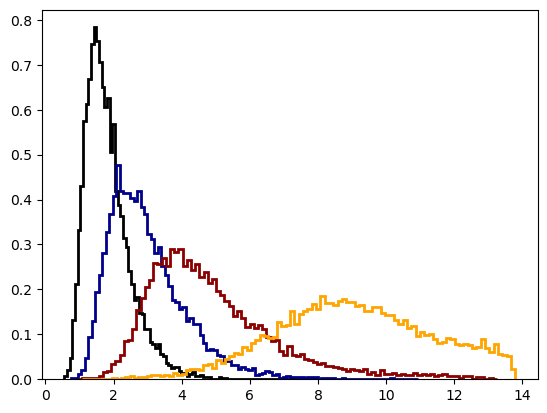

In [27]:
plt.hist(df99['t_form_10'],lw=2,bins=100,color='black',density=True,histtype='step')
plt.hist(df99['t_form_25'],lw=2,bins=100,color='darkblue',density=True,histtype='step')
plt.hist(df99['t_form_50'],lw=2,bins=100,color='darkred',density=True,histtype='step')
plt.hist(df99['t_form_90'],lw=2,bins=100,color='orange',density=True,histtype='step')

plt.show()